# Model Evaluation and SHAP Explainability
## Health Insurance Fraud Detection System

**Purpose:** 
1. Load trained models from Notebook 02
2. Generate SHAP explanations for interpretability
3. Analyze feature importance
4. Create detailed visualizations for thesis
5. Export results for dashboard integration

---

## 1. Setup and Imports

In [1]:
# Data manipulation
import pandas as pd
import numpy as np
import pickle

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.metrics import (
    precision_score, recall_score, f1_score, 
    roc_auc_score, average_precision_score, 
    roc_curve, precision_recall_curve,
    confusion_matrix
)

# SHAP for explainability
import shap

# Keras for loading autoencoder
import keras
from keras import layers, models

# Utilities
import warnings
import os
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("✅ All imports successful!")

✅ All imports successful!


## 2. Load Data and Models

In [3]:
# Load preprocessed data
X_train = np.load('../data/processed/X_train.npy')
X_test = np.load('../data/processed/X_test.npy')
y_train = np.load('../data/processed/y_train.npy')
y_test = np.load('../data/processed/y_test.npy')

# Load feature names
with open('../data/processed/feature_names.txt', 'r') as f:
    feature_names = f.read().splitlines()

# Load scores from training notebook
if_scores = np.load('../data/processed/if_scores.npy')
ocsvm_scores = np.load('../data/processed/ocsvm_scores.npy')
lof_scores = np.load('../data/processed/lof_scores.npy')
ae_scores = np.load('../data/processed/ae_scores.npy')
ensemble_scores = np.load('../data/processed/ensemble_scores.npy')

# Load models
with open('../models/isolation_forest.pkl', 'rb') as f:
    if_model = pickle.load(f)

with open('../models/one_class_svm.pkl', 'rb') as f:
    ocsvm_model = pickle.load(f)

with open('../models/lof.pkl', 'rb') as f:
    lof_model = pickle.load(f)

# Load autoencoder
autoencoder = models.load_model('../models/autoencoder.h5', compile=False)

# Load results from training notebook
results_df = pd.read_csv('../data/processed/model_results.csv', index_col=0)

print("✅ Data and models loaded successfully!")
print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Test set: {X_test.shape[0]:,} samples")
print(f"Features: {len(feature_names)}")


✅ Data and models loaded successfully!
Training set: 8,000 samples
Test set: 2,000 samples
Features: 10


## 3. Detailed Model Evaluation

### 3.1 Confusion Matrices

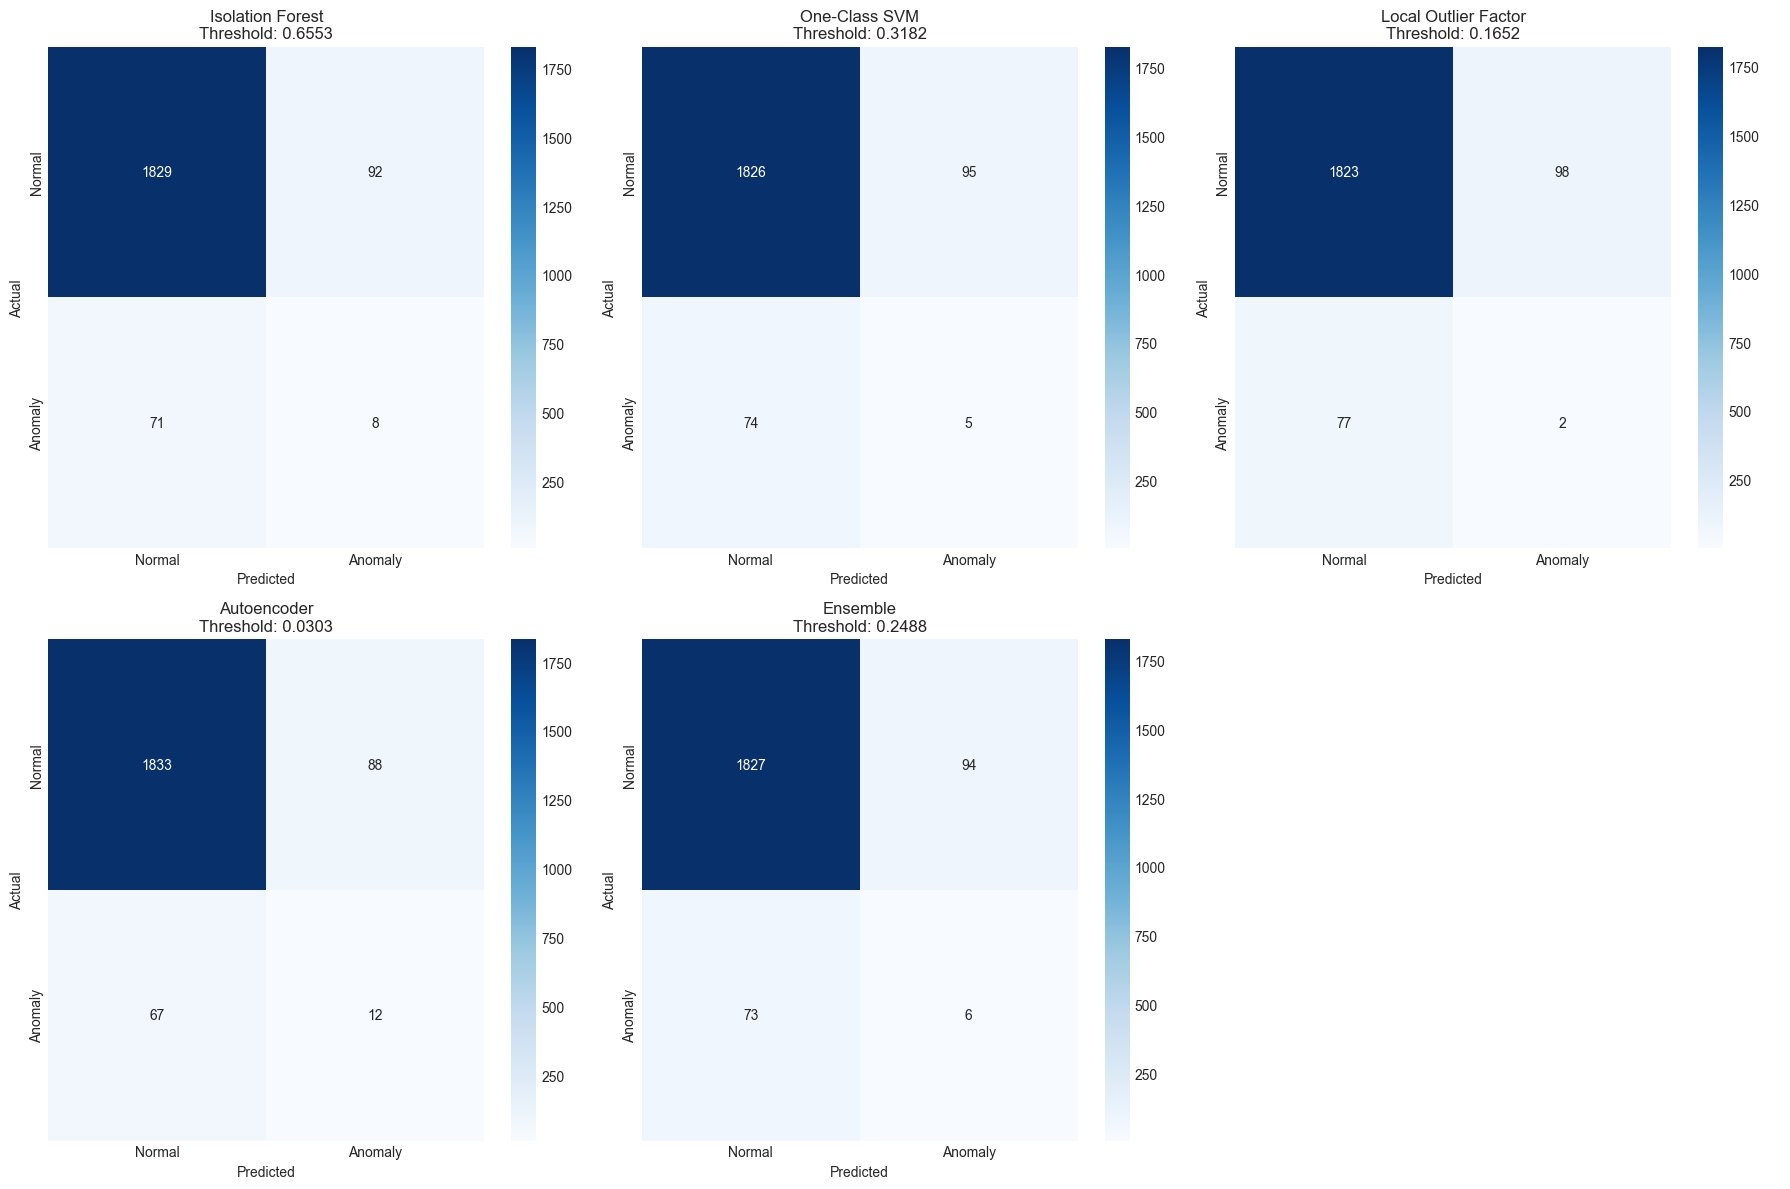

In [4]:
def plot_confusion_matrix(y_true, scores, threshold=None, title='Confusion Matrix'):
    """
    Plot confusion matrix at optimal threshold.
    """
    if threshold is None:
        # Use 95th percentile as threshold
        threshold = np.percentile(scores, 95)
    
    y_pred = (scores >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Anomaly'],
                yticklabels=['Normal', 'Anomaly'])
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('Actual', fontsize=12)
    ax.set_title(title, fontsize=14)
    
    return fig

# Create confusion matrices for all models
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

models = [
    ('Isolation Forest', if_scores),
    ('One-Class SVM', ocsvm_scores),
    ('Local Outlier Factor', lof_scores),
    ('Autoencoder', ae_scores),
    ('Ensemble', ensemble_scores)
]

for i, (name, scores) in enumerate(models):
    threshold = np.percentile(scores, 95)
    y_pred = (scores >= threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Normal', 'Anomaly'],
                yticklabels=['Normal', 'Anomaly'])
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
    axes[i].set_title(f'{name}\nThreshold: {threshold:.4f}')

# Hide empty subplot
axes[5].axis('off')

plt.tight_layout()
plt.savefig('../figures/confusion_matrices.png', dpi=300)
plt.show()